# Monte Carlo Portfolio Simulation

This notebook generates thousands of random portfolio allocations to explore the feasible risk-return space.

For each simulated portfolio, we calculate:
- expected annual return,
- annual volatility,
- Sharpe ratio.

The simulation provides an intuitive visualization of the risk-return trade-off and the efficient frontier.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

In [3]:
tickers = [
    "AAPL",
    "MSFT",
    "JPM",
    "JNJ",
    "XOM",
    "PG",
    "CAT",
    "NEE"
]

start_date = "2016-01-01"
end_date = "2026-01-01"

data = yf.download(
    tickers,
    start=start_date,
    end=end_date,
    auto_adjust=True,
    progress=False
)

prices = data["Close"]

returns = prices.pct_change().dropna()

mu = returns.mean() * 252
cov_matrix = returns.cov() * 252

In [4]:
n_assets = len(tickers)

random_weights = np.random.random(n_assets)

random_weights

array([0.3558611 , 0.24003028, 0.01913669, 0.41355516, 0.97753109,
       0.85330161, 0.32851393, 0.39640844])

In [5]:
random_weights.sum()

np.float64(3.584338293119384)

In [6]:
random_weights = random_weights / random_weights.sum()

random_weights

array([0.09928223, 0.06696641, 0.00533897, 0.11537838, 0.27272289,
       0.23806391, 0.0916526 , 0.11059459])

In [7]:
random_weights.sum()

np.float64(1.0)

In [8]:
risk_free_rate = 0
random_return = random_weights @ mu

random_variance = (
    random_weights
    @ cov_matrix
    @ random_weights
)

random_volatility = np.sqrt(random_variance)

random_sharpe = (
    random_return - risk_free_rate
) / random_volatility

In [9]:
print(f"Return: {random_return:.2%}")
print(f"Volatility: {random_volatility:.2%}")
print(f"Sharpe: {random_sharpe:.2f}")

Return: 21.17%
Volatility: 18.25%
Sharpe: 1.16


## Simulating Random Portfolios

We generate 10,000 long-only portfolios.

For each portfolio, random positive weights are generated and normalized so that the portfolio weights sum to one.

In [10]:
n_portfolios = 10000

portfolio_returns = np.zeros(n_portfolios)
portfolio_volatilities = np.zeros(n_portfolios)
portfolio_sharpes = np.zeros(n_portfolios)

all_weights = np.zeros((n_portfolios, n_assets))

In [11]:
for i in range(n_portfolios):
    weights = np.random.random(n_assets)
    weights = weights / weights.sum()
    
    portfolio_return = weights @ mu

    portfolio_variance = (
        weights
        @ cov_matrix
        @ weights
    )

    portfolio_volatility = np.sqrt(portfolio_variance)

    portfolio_sharpe = (
        portfolio_return - risk_free_rate
    ) / portfolio_volatility

    portfolio_returns[i] = portfolio_return
    portfolio_volatilities[i] = portfolio_volatility
    portfolio_sharpes[i] = portfolio_sharpe

    all_weights[i] = weights

In [12]:
simulation_results = pd.DataFrame({
    "Return": portfolio_returns,
    "Volatility": portfolio_volatilities,
    "Sharpe": portfolio_sharpes
})

simulation_results.head()

,Return,Volatility,Sharpe
0,0.198799,0.174726,1.137776
1,0.215213,0.180971,1.189215
2,0.164702,0.162410,1.014111
3,0.199352,0.179472,1.110771
4,0.216413,0.184307,1.174198


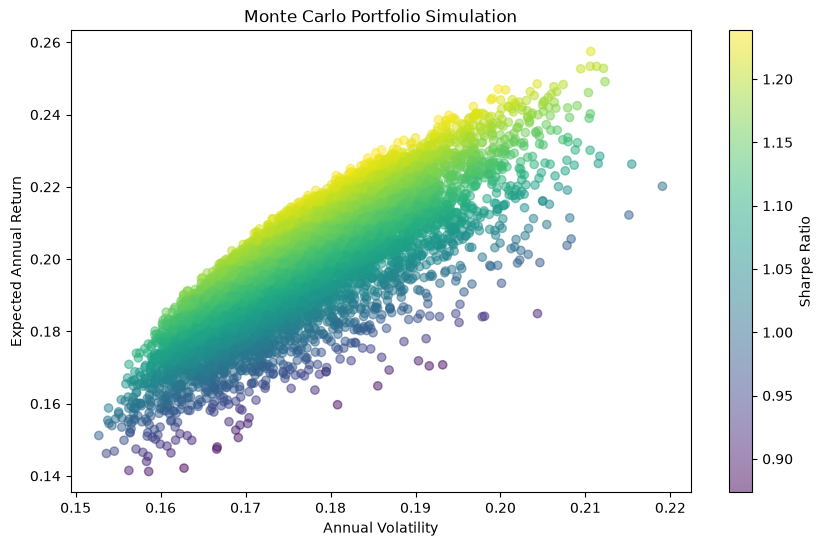

In [13]:
plt.figure(figsize=(10, 6))

scatter = plt.scatter(
    portfolio_volatilities,
    portfolio_returns,
    c=portfolio_sharpes,
    alpha=0.5
)

plt.xlabel("Annual Volatility")
plt.ylabel("Expected Annual Return")
plt.title("Monte Carlo Portfolio Simulation")

plt.colorbar(scatter, label="Sharpe Ratio")

plt.show()

In [14]:
max_sharpe_index = np.argmax(portfolio_sharpes)
max_sharpe_return = portfolio_returns[max_sharpe_index]
max_sharpe_volatility = portfolio_volatilities[max_sharpe_index]
max_sharpe_weights = all_weights[max_sharpe_index]
print(f"Return: {max_sharpe_return:.2%}")
print(f"Volatility: {max_sharpe_volatility:.2%}")
print(f"Sharpe: {portfolio_sharpes[max_sharpe_index]:.2f}")

Return: 23.86%
Volatility: 19.27%
Sharpe: 1.24


In [15]:
pd.Series(
    max_sharpe_weights,
    index=tickers
).sort_values(ascending=False)

XOM     0.258700
MSFT    0.250041
PG      0.212864
AAPL    0.168858
JPM     0.050811
CAT     0.046162
JNJ     0.010253
NEE     0.002310
dtype: float64

In [16]:
min_vol_index = np.argmin(portfolio_volatilities)
min_vol_return = portfolio_returns[min_vol_index]
min_volatility = portfolio_volatilities[min_vol_index]
min_vol_weights = all_weights[min_vol_index]
print(f"Return: {min_vol_return:.2%}")
print(f"Volatility: {min_volatility:.2%}")
print(f"Sharpe: {portfolio_sharpes[min_vol_index]:.2f}")

Return: 15.12%
Volatility: 15.27%
Sharpe: 0.99


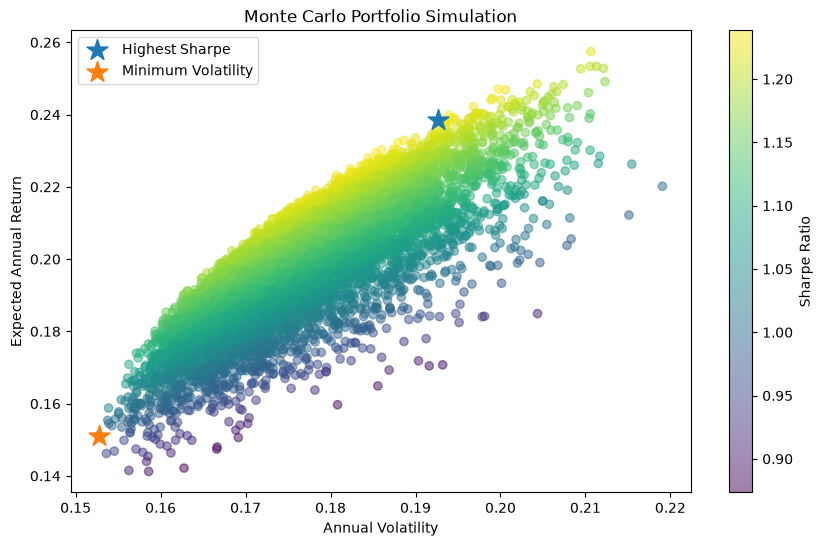

In [17]:
plt.figure(figsize=(10, 6))

scatter = plt.scatter(
    portfolio_volatilities,
    portfolio_returns,
    c=portfolio_sharpes,
    alpha=0.5
)

plt.scatter(
    max_sharpe_volatility,
    max_sharpe_return,
    marker="*",
    s=250,
    label="Highest Sharpe"
)

plt.scatter(
    min_volatility,
    min_vol_return,
    marker="*",
    s=250,
    label="Minimum Volatility"
)

plt.xlabel("Annual Volatility")
plt.ylabel("Expected Annual Return")
plt.title("Monte Carlo Portfolio Simulation")

plt.colorbar(scatter, label="Sharpe Ratio")
plt.legend()

plt.show()

## Conclusion

The Monte Carlo simulation illustrates the feasible risk-return combinations generated by different long-only portfolio allocations.

The simulated minimum-volatility and maximum-Sharpe portfolios provide approximate solutions because only a finite number of random portfolios are evaluated. In the next notebook, numerical optimization is used to solve these portfolio objectives directly.